## Setup

In [ ]:
#FPGA notebook
from tqdm.notebook import tqdm
from qick import *
%pylab inline
import h5py
import json
from scipy.signal import find_peaks

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
from flask import Flask, jsonify, request
import threading
import time
import numpy as np
import logging

ENABLE_FLASK_LOGS = False
if not ENABLE_FLASK_LOGS:
    log = logging.getLogger('werkzeug')
    log.setLevel(logging.ERROR)

app = Flask(__name__)

# ---- shared state (used by all measurement styles) ----
measurement_ready = True
current_data = None
pc_done = False

currents_array = None
angles_array = None

heatmap_data = None
time_axis = None
currents = None
fpts = None
config = {}  # IMPORTANT: always exists

last_complete_caen1_idx = None

In [ ]:
import json

@app.route('/ready', methods=['GET'])
def ready():
    return jsonify({'ready': measurement_ready, 'data': current_data})

@app.route('/reset', methods=['GET'])
def reset():
    global measurement_ready
    measurement_ready = False
    return jsonify({'status': 'reset'})

@app.route('/status', methods=['GET'])
def status():
    return jsonify({'server': 'running'})

@app.route('/pc_done', methods=['POST'])
def pc_done_handler():
    global pc_done
    pc_done = True
    return "PC done acknowledged", 200

@app.route('/set_currents', methods=['POST'])
def set_currents():
    global currents_array
    data = request.json
    currents_array = np.array(data['currents'], dtype=float)
    return jsonify({'status': 'success', 'length': int(len(currents_array))})

@app.route('/get_data', methods=['GET'])
def get_data():
    global heatmap_data, time_axis, currents, fpts, config, last_complete_caen1_idx

    caen1_idx = request.args.get('caen1_idx', None)
    if caen1_idx is not None:
        caen1_idx = int(caen1_idx)
        if last_complete_caen1_idx != caen1_idx:
            return jsonify({'status': 'not_ready'}), 409

    if heatmap_data is None:
        return jsonify({'status': 'not_ready'}), 409

    heatmap_arr = np.array(heatmap_data)
    return jsonify({
        'status': 'ok',
        'amplitude': np.abs(heatmap_arr).tolist(),
        'phase': np.angle(heatmap_arr).tolist(),
        'time_axis': time_axis.tolist() if time_axis is not None else [],
        'currents': currents.tolist() if currents is not None else [],
        'fpts': fpts.tolist() if fpts is not None else [],
        'config': json.dumps(config) if config else "{}"
    })

@app.route("/measure", methods=["POST"])
def measure():

    config = request.get_json()
    prog =LoopbackProgram(soccfg, config) 
    adc1 = prog.acquire_decimated(soc, progress=False)

    return jsonify({ "status": "success" })



In [4]:
import threading
from werkzeug.serving import make_server

class FlaskServer:
    def __init__(self):
        self.server = None
        self.thread = None

    def start(self, port=5000):
        if self.server is not None:
            print("Server already running.")
            return
        self.server = make_server('0.0.0.0', port, app)
        self.thread = threading.Thread(target=self.server.serve_forever, daemon=True)
        self.thread.start()
        print(f"Flask server started on http://10.22.197.200:{port}")

    def stop(self):
        if self.server is None:
            print("No server running")
            return
        self.server.shutdown()
        self.thread.join()
        self.server = None
        self.thread = None
        print("Flask server stopped")

flask_server = FlaskServer()

In [5]:
import os

global_max_file = "global_max_amplitude.txt"

# Read existing max or initialise
if os.path.exists(global_max_file):
    with open(global_max_file, "r") as f:
        global_max = float(f.read().strip())
    print(f"Loaded global max: {global_max}")
else:
    global_max = 0.0
    print("No existing global max found, starting fresh")

def update_global_max(new_max):
    """Update global max if new value is larger"""
    global global_max
    if new_max > global_max:
        global_max = new_max
        with open(global_max_file, "w") as f:
            f.write(str(global_max))
        print(f"Updated global max: {global_max}")
    return global_max

Loaded global max: 2943.0044508673445


In [6]:
soc = QickSoc()
soccfg = soc
print(soccfg)


QICK configuration:

	Board: RFSoC4x2

	Software version: 0.2.267
	Firmware timestamp: Wed Sep  6 18:49:29 2023

	Global clocks (MHz): tProcessor 409.600, RF reference 491.520

	2 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 65536 samples (6.667 us)
		fs=9830.400 MHz, fabric=614.400 MHz, 32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 0 is DAC_B
	1:	axis_signal_gen_v6 - envelope memory 65536 samples (6.667 us)
		fs=9830.400 MHz, fabric=614.400 MHz, 32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is DAC_A

	2 readout channels:
	0:	axis_readout_v2 - configured by PYNQ
		fs=4423.680 MHz, decimated=552.960 MHz, 32-bit DDS, range=4423.680 MHz
		maxlen 16384 accumulated, 1024 decimated (1.852 us)
		triggered by output 7, pin 14, feedback to tProc input 0
		ADC tile 0, blk 0 is ADC_D
	1:	axis_readout_v2 - configured by PYNQ
		fs=4423.680 MHz, decimated=552.960 MHz, 32-bit DDS, range=4423.680 MHz
		maxlen 16384 accumulated, 1024 decimated (1.852 us)
		triggered by o

### Hardware Configuration

You should cable the board in loopback, connecting one DAC to one ADC. You can set appropriate generator and readout numbers in the cell below, which will be used in `res_ch` and `ro_chs` entries in the program dictionaries below.

- start with nothing

In [7]:
class LoopbackProgram(AveragerProgram): #inherit from AveragerProgram
    def initialize(self):
        cfg=self.cfg #get config
        res_ch = cfg["res_ch"] #DAC channel select
        # configure DAC - set the nyquist zone
        self.declare_gen(ch=cfg["res_ch"], nqz=1)        

        # configure ADC - set the readout lengths and downconversion frequencies (ensuring it is an available DAC frequency)
        # 
        for ch in cfg["ro_chs"]:        
            self.declare_readout(
                ch=ch, 
                length=self.cfg["readout_length"],
                freq=self.cfg["pulse_freq"], 
                gen_ch=cfg["res_ch"]
            )

        # convert frequency to DAC frequency (ensuring it is an available ADC frequency)
        freq = self.freq2reg(cfg["pulse_freq"],gen_ch=res_ch, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]
        self.default_pulse_registers(ch=res_ch, freq=freq, phase=phase, gain=gain)

        # configure pulse style (ie. square, sinc, etc.)
        style=self.cfg["pulse_style"]

        if style in ["flat_top","arb"]:
            sigma = cfg["sigma"]
            self.add_gauss(ch=res_ch, name="measure", sigma=sigma, length=sigma*5)
        if style == "const":
            self.set_pulse_registers(ch=res_ch, style=style, length=cfg["length"])
        elif style == "flat_top":
            # The first half of the waveform ramps up the pulse, the second half ramps down the pulse
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure", length=cfg["length"])
        elif style == "arb":
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure")
        
        self.synci(200)  # give processor some time to configure pulses [clock ticks]
    
    def body(self):
        # fire the pulse
        # trigger all declared ADCs
        # pulse PMOD0_0 for a scope trigger
        # pause the tProc until readout is done
        # increment the time counter to give some time before the next measurement
        # (the syncdelay also lets the tProc get back ahead of the clock)
        
        # self.measure(pulse_ch=self.cfg["res_ch"], 
        #              adcs=self.ro_chs,
        #              pins=[0], 
        #              adc_trig_offset=self.cfg["adc_trig_offset"],
        #              wait=True,
        #              syncdelay=self.us2cycles(self.cfg["relax_delay"]))
        
        # equivalent to the following:
        self.trigger(adcs=self.ro_chs,
                     pins=[0], 
                     adc_trig_offset=self.cfg["adc_trig_offset"])
        self.pulse(ch=self.cfg["res_ch"])
        self.wait_all()
        self.sync_all(self.us2cycles(self.cfg["relax_delay"]))

In [ ]:
import zmq
import numpy as np

# Import your QICK libraries here
#from qick import *


class FPGAController:

    def __init__(self):
        """
        Initialise the connection to the FPGA.
        """

        # This is where your existing QICK connection goes.
        #
        # For example, depending on your setup:
        #
        # self.soc = QickSoc()
        #
        # or:
        #
        # self.soc = QickSoc("...")
        #
        # Use whatever you currently have working
        # in your FPGA-side Jupyter notebook.

        #self.soc = QickSoc()

        self.config = None
        self.frequency = None


    def configure(self, config):
        """
        Store/configure the measurement parameters.
        """

        self.config = config

        # Your QICK program configuration would
        # be handled here.

        print("FPGA configured:")
        print(config)


    def set_frequency(self, frequency):
        """
        Set the frequency for the next measurement.
        """

        self.frequency = frequency

        print(f"Frequency set to {frequency} Hz")

        # Your actual QICK frequency configuration
        # goes here.


    def measure(self):
        """
        Perform one FPGA acquisition.

        Returns
        -------
        iq : numpy.ndarray
            Complex IQ samples.
        """

        if self.config is None: raise RuntimeError( "FPGA has not been configured" )

        if self.frequency is None: raise RuntimeError( "Frequency has not been set" )


        # ==================================================
        # YOUR EXISTING QICK ACQUISITION CODE GOES HERE
        # ==================================================

        #
        # For example:
        #
        # prog = MyProgram(
        #     self.soc,
        #     self.config
        # )
        #
        # adc = self.soc.acquire(
        #     prog
        # )
        #

        adc = ()


        # ==================================================
        # Convert the returned ADC data to complex IQ
        # ==================================================

        I = adc[:, 0]
        Q = adc[:, 1]

        iq = ( I.astype(np.float32) + 1j * Q.astype(np.float32) )

        return iq


    

    def status(self):

        return { "connected": True, "frequency": self.frequency, "configured": self.config is not None }

# ==========================================================
# ZeroMQ server
# ==========================================================

class FPGAServer:

    def __init__( self, fpga, port=5555 ):

        self.fpga = fpga

        self.context = zmq.Context()

        self.socket = self.context.socket( zmq.REP )

        self.socket.bind( f"tcp://0.0.0.0:{port}" )

        print( f"FPGA server listening on port {port}" )


    def run(self):

        while True:

            try:

                # ------------------------------------------
                # Receive command
                # ------------------------------------------

                request = self.socket.recv_json()

                command = request.get("command")
                parameters = request.get( "parameters", {} )

                print( f"Received command: {command}" )


                # ------------------------------------------
                # Handle command
                # ------------------------------------------

                if command == "configure":

                    config = parameters["config"]

                    self.fpga.configure(config)

                    self.socket.send_json({ "status": "ok" })


                elif command == "set_frequency":

                    frequency = parameters["frequency"]

                    self.fpga.set_frequency( frequency )

                    self.socket.send_json({ "status": "ok" })


                elif command == "measure":

                    iq = self.fpga.measure()

                    # Send binary NumPy array
                    self.socket.send( iq.astype( np.complex64 ).tobytes() )


                elif command == "status":

                    status = self.fpga.status()

                    self.socket.send_json({ "status": "ok", "data": status })


                else:

                    self.socket.send_json({ "status": "error", "error": f"Unknown command: {command}" })


            except Exception as e:

                print( f"Error: {e}" )

                self.socket.send_json({ "status": "error", "error": str(e) })


# ==========================================================
# Main
# ==========================================================

if __name__ == "__main__":

    fpga = FPGAController()

    server = FPGAServer( fpga, port=5555 )

    server.run()

## Alban demo

In [9]:
#GEN_CH = 0-1 for DAC_B-DAC_A 
#RO_CH = 0-4 for ADC_D-ADC_A

GEN_CH = 1 # DAC A
RO_CH = 1  # ADC C

# GEN_CH_B = 0 # DAC B
# RO_CH_D = 0  # ADC D

config={"res_ch":GEN_CH, # --Fixed
        "ro_chs":[RO_CH], # --Fixed
        "reps":1, # --Fixed
        "relax_delay":1.0, # --us
        "res_phase":0, # --degrees
        "pulse_style": "const", # --Fixed

        # Try varying  length from 10-100 clock ticks
        "sigma": 50, # [Clock ticks]
        # Try varying sigma from 10-50 clock ticks
        
        "length":300, # [Clock ticks]
        # Try varying length from 10-100 clock ticks
        
        "readout_length":100, # [Clock ticks]
        # Try varying readout_length from 50-1000 clock ticks

        "pulse_gain":40000, # [DAC units]
        # Try varying pulse_gain from 500 to 30000 DAC units

        "adc_trig_offset": 250, # [Clock ticks]
        # Try varying adc_trig_offset from 100 to 220 clock ticks
        # I think this is like how many ticks until the ADC starts listening

        "soft_avgs":200
        # Try varying soft_avgs from 1 to 200 averages

       }


i=[]
q=[]

#Declare no. of points and start/end freqs
steps = 1001
expt_cfg = {
    "start": 6286,
    "end": 6536,
}

fpts = np.linspace(expt_cfg["start"], expt_cfg["end"], steps)

#Adjust freq in'config' and measure  
for f in tqdm(fpts): 

    config["pulse_freq"] = f
    
    prog =LoopbackProgram(soccfg, config) 
    adc1 = prog.acquire_decimated(soc, progress=False)
    
    i.append(np.abs(adc1[0][0] + 1j * adc1[0][1]))
    
i = np.array(i)

S21 = np.abs(i)
S21 = np.array(S21)

time_axis = soccfg.cycles2us(np.arange(config["readout_length"]), gen_ch=GEN_CH)
update_global_max(np.max(S21))

  0%|          | 0/1001 [00:00<?, ?it/s]

2943.0044508673445

Peaks at: []
Dips at: []


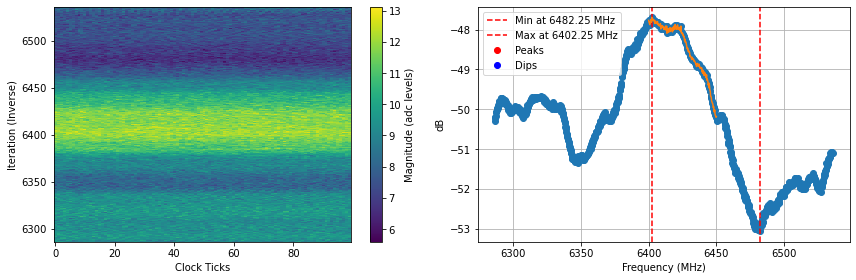

In [10]:
log_S21_data = np.where(S21 != 0, 20 * np.log10(S21 / global_max), -40.0)
# log_S21_data = np.log10(S21/np.max(S21))

plt.figure(figsize=(12, 4))  
plt.subplot(1, 2, 1)
plt.pcolormesh(np.arange(config["readout_length"]), fpts, S21, cmap='viridis', shading='auto')
# Labels and title
plt.xlabel("Clock Ticks")
plt.ylabel("Iteration (Inverse)")
plt.colorbar(label="Magnitude (adc levels)")
# plt.xlim(0,80)



average_vertical_slice = np.mean(log_S21_data, axis=1)
vertical_slice = log_S21_data[:, 5]

# Mask to region of interest
mask = (fpts >= 6400) & (fpts <= 6450)
fpts_roi = fpts[mask]
data_roi = average_vertical_slice[mask]

peaks, _ = find_peaks(data_roi, prominence=0.25)
dips, _ = find_peaks(-data_roi, prominence=0.25)

peak_freqs = fpts_roi[peaks]
dip_freqs = fpts_roi[dips]

print("Peaks at:", peak_freqs)
print("Dips at:", dip_freqs)

plt.subplot(1, 2, 2)
plt.plot(fpts, average_vertical_slice, marker='o')
# plt.plot(fpts, vertical_slice, marker='o')
plt.xlabel("Frequency (MHz)")
plt.ylabel("dB")
plt.grid(True)
min_freq = fpts[np.argmin(average_vertical_slice)]
plt.axvline(min_freq, color='r', linestyle='--', label=f'Min at {min_freq:.2f} MHz')
max_freq = fpts[np.argmax(average_vertical_slice)]
plt.axvline(max_freq, color='r', linestyle='--', label=f'Max at {max_freq:.2f} MHz')

plt.plot(fpts_roi, data_roi)
plt.plot(fpts_roi[peaks], data_roi[peaks], 'ro', label='Peaks')
plt.plot(fpts_roi[dips], data_roi[dips], 'bo', label='Dips')
plt.legend()

plt.legend()
plt.tight_layout()
plt.show()

In [11]:
fr=min_freq
# fr=max_freq
# fr=fpts_roi[peaks][-1]
# fr=4997
print(fr)
# print(fpts_total)

6482.25


## FMR Sweep using big magnet

5/10/26: FPGA 'pulse style = const' generates an AC signal of frequency 'pulse freq'. Previously thought 'const' generates a square wave. Thus must effectively excite the YIG sample for all freqs across magnetic field strength (FMR). 

So FPGA experimentation will consist of a VNA style frequency sweep coupled with the magnet for resonance frequencies for all magnetic field strengths tested ('fmr sweep') followed by a sweep through the same magnetic field stengths with a short time-domain pulse with the pulse freq set to the fmr frequency for that corresponding magnetic field stength ('pulse sweep'). 

For 'FMR Sweep';   start flask server -> receive freqs + currents from PC           -> measure + send data to PC -> stop server

For 'Pulse Sweep'; start flask server -> receive resonance freqs + currents from PC -> measure + send data to PC -> stop server

The PC notebook should take on the bulk of the workload as opposed to the FPGA. FPGA should be treated similar to VNA in the sense that all configuration and setup is done on th PC end. FPGA should simply take config file from PC and send recorded data back to PC. This reduces a lot of overhead caused by constant parity checks and completely eliminates any issues caused by it.

In [ ]:
#fmr sweep
#start flask server
flask_server.stop()

measurement_ready = True
currents_array = None  # currents to sweep (set by PC)
current_data = None # data to send to PC

frequencies_array = None # frequencies to sweep (set by PC)
frequencies_data = None 

flask_server.start()
print("Server started")
pc_done = False

#receive (freq + currents) from PC

print("Waiting for frequencies from PC...")
while frequencies_array is None:
    time.sleep(0.1)
lenFreqs = len(currents_array)
print(f"Received {lenFreqs} frequency values from PC")

print("Waiting for currents from PC...")
while currents_array is None:
    time.sleep(0.1)
lenCurrents = len(currents_array)
print(f"Received {lenCurrents} current values from PC")

print("ready to measure")
#measure + send data to PC
for i in currents_array:
    #ensure fpga current and pc current match before continuing


#sweep all frequencies for each current then send to PC



#stop server

## 3D Sweep (time, amplitude, CAEN2040)

In [ ]:
soc = QickSoc()
soccfg = soc

In [ ]:
GEN_CH = 1       # DAC A
RO_CH = 1        # ADC C

config = {
    "res_ch": GEN_CH,
    "ro_chs": [RO_CH],
    "reps": 1,
    "relax_delay": 1.0,
    "res_phase": 0,
    "pulse_style": "const",

    "sigma": 50,
    "length": 5,
    "readout_length": 1000,

    "pulse_gain": 40000,
    "pulse_freq": fr,

    "adc_trig_offset": 0,

    "soft_avgs": 200
}

prog = LoopbackProgram(soccfg, config)

iq_list = prog.acquire_decimated(soc, progress=True)


# =========================================================
# Extract I and Q
# =========================================================

iq = iq_list[0]

I = iq[0]
Q = iq[1]


# =========================================================
# Create time axis
# =========================================================

clock_ticks = np.arange(len(I))

time_axis_us = soccfg.cycles2us(clock_ticks, gen_ch=GEN_CH)

time_axis_ns = time_axis_us * 1000


# =========================================================
# Calculate amplitude and phase
# =========================================================

S21 = np.abs(I + 1j * Q)

phase = np.degrees(np.angle(I + 1j * Q))


# =========================================================
# Calculate dB
# =========================================================

S21_max = np.max(S21)
update_global_max(S21_max)
S21_dB = 20 * np.log10(S21 / global_max)

# Generate unique measurement ID

measurement_id = get_next_measurement_id()
timestamp = datetime.now().isoformat(timespec="seconds")
filename = DATA_DIR / (f"measurement_{measurement_id}.h5")

with h5py.File(filename, "w") as f:

    f.create_dataset("I",data=I)
    f.create_dataset("Q",data=Q)

    # -----------------------------------------------------
    # Processed data
    # -----------------------------------------------------

    f.create_dataset(
        "S21",
        data=S21
    )

    f.create_dataset(
        "phase",
        data=phase
    )

    f.create_dataset(
        "S21_dB",
        data=S21_dB
    )


    # -----------------------------------------------------
    # Time information
    # -----------------------------------------------------

    f.create_dataset(
        "clock_ticks",
        data=clock_ticks
    )

    f.create_dataset(
        "time_us",
        data=time_axis_us
    )

    f.create_dataset(
        "time_ns",
        data=time_axis_ns
    )


    # =====================================================
    # Experiment metadata
    # =====================================================

    f.attrs["measurement_id"] = measurement_id    # Unique measurement identifier

    f.attrs["timestamp"] = timestamp     # Timestamp

    # -----------------------------------------------------
    # configuration data
    # -----------------------------------------------------

    f.attrs["GEN_CH"] = GEN_CH
    f.attrs["RO_CH"] = RO_CH

    f.attrs["pulse_freq_MHz"] = config["pulse_freq"]
    f.attrs["pulse_gain"] = config["pulse_gain"]
    f.attrs["sigma"] = config["sigma"]
    f.attrs["length"] = config["length"]

    f.attrs["readout_length"] = config["readout_length"]
    f.attrs["adc_trig_offset"] = config["adc_trig_offset"]
    # Acquisition configuration
    f.attrs["soft_avgs"] = config["soft_avgs"]
    f.attrs["reps"] = config["reps"]
    f.attrs["relax_delay_us"] = config["relax_delay"]
    # Results
    f.attrs["S21_max"] = S21_max
    f.attrs["global_max"] = global_max

    
print( f"Saved measurement {measurement_id} "f"to {filename}")



In [12]:
#is this needed?? (from cell below)
def acquire_with_retry(prog, max_retries=3):
    global soc, soccfg
    for attempt in range(max_retries):
        try:
            return prog.acquire_decimated(soc, progress=False)
        except (RuntimeError, ValueError) as e:
            if attempt < max_retries - 1:
                print(f"DMA error, reinitialising (attempt {attempt + 1})...")
                soc = QickSoc()
                soccfg = soc
                time.sleep(0.5)
                continue
            raise

In [13]:
# ---------------------------------
# start flask server
# ----------------------------------
flask_server.stop() #stop any existing server
measurement_ready = True
current_data = None
currents_array = None  # Will be set by /set_currents endpoint
flask_server.start()
print("Server restarted, ready for measurements")
pc_done = False

# ---------------------------------
# Initialise variables
# ---------------------------------

ENABLE_FPGA_LOGS = False  # Set to True for debugging

# --------------------------------------
# Wait for PC to send currents array
# --------------------------------------

print("Waiting for currents from PC...")
while currents_array is None:
    time.sleep(0.1)
noOfSteps = len(currents_array)
print(f"Received {noOfSteps} current values from PC")

# --------------------------------------
# Take measurement
# --------------------------------------

for iteration in tqdm(range(noOfSteps)):
    # WAIT for PC to set the current first
    if ENABLE_FPGA_LOGS:
        print(f"Iteration {iteration}: Waiting for PC to set current...")
    # Wait for PC to signal it has set the current (by resetting the flag)
    while measurement_ready:
        time.sleep(0.1)
    if ENABLE_FPGA_LOGS:
        print(f"PC has set current, starting measurement {iteration}")
    
    # Now do the measurement
    amps = []
    phases = []
    for f in fpts:
        config["pulse_freq"] = f
        prog = LoopbackProgram(soccfg, config)
        adc1 = acquire_with_retry(prog)
        amps.append(np.abs(adc1[0][0] + 1j * adc1[0][1]))
        phases.append(np.angle(adc1[0][0] + 1j * adc1[0][1]))  # Store phase
    
    for k in range(len(fpts)):
        heatmap_data[k].append(amps[k])
        heatmap_phase[k].append(phases[k])
    
    # Store measurement data and signal completion
    current_data = {
            'iteration': iteration,
            'max_signal': float(np.max(amps)),
            'amps': [float(x) for x in amps],
            'phases': [float(x) for x in phases],
            'timestamp': time.time()
        }

    measurement_ready = True
    if ENABLE_FPGA_LOGS:
        print(f"Measurement {iteration} complete, signaling PC...")

print("All measurements complete!")

# ------------------------------------
# Let PC finish + stop server
# ------------------------------------

# Wait for PC to confirm it's done
while not pc_done:
    time.sleep(0.1)
    
# Now it's safe to stop the server
flask_server.stop()
print("Server stopped")

# ------------------------------------
# Format data
# ------------------------------------

heatmap_data = np.array(heatmap_data)
heatmap_phase = np.array(heatmap_phase)
currents = currents_array
update_global_max(np.max(heatmap_data))

fr_index = np.where(fpts == fr)[0][0]


No server running
Flask server started on http://10.22.197.200:5000
Server restarted, ready for measurements
Waiting for currents from PC...
Received 575 current values from PC


  0%|          | 0/575 [00:00<?, ?it/s]


KeyboardInterrupt



In [ ]:
# ---------------------------------
# start flask server
# ----------------------------------
flask_server.stop() #stop any existing server
measurement_ready = True
current_data = None
currents_array = None  # Will be set by /set_currents endpoint
flask_server.start()
print("Server restarted, ready for measurements")
pc_done = False

# ---------------------------------
# Initialise variables
# ---------------------------------

fpts = np.linspace(fr - 6, fr + 6, 25) # got rid of fine/ coarse declarations


heatmap_data = [[] for _ in range(len(fpts))]
heatmap_phase = [[] for _ in range(len(fpts))]  # Store phase data

ENABLE_FPGA_LOGS = False  # Set to True for debugging

# --------------------------------------
# Wait for PC to send currents array
# --------------------------------------

print("Waiting for currents from PC...")
while currents_array is None:
    time.sleep(0.1)
noOfSteps = len(currents_array)
print(f"Received {noOfSteps} current values from PC")

# --------------------------------------
# Take measurement
# --------------------------------------

for iteration in tqdm(range(noOfSteps)):
    # WAIT for PC to set the current first
    if ENABLE_FPGA_LOGS:
        print(f"Iteration {iteration}: Waiting for PC to set current...")
    # Wait for PC to signal it has set the current (by resetting the flag)
    while measurement_ready:
        time.sleep(0.1)
    if ENABLE_FPGA_LOGS:
        print(f"PC has set current, starting measurement {iteration}")
    
    # Now do the measurement
    amps = []
    phases = []
    for f in fpts:
        config["pulse_freq"] = f
        prog = LoopbackProgram(soccfg, config)
        adc1 = acquire_with_retry(prog)
        amps.append(np.abs(adc1[0][0] + 1j * adc1[0][1]))
        phases.append(np.angle(adc1[0][0] + 1j * adc1[0][1]))  # Store phase
    
    for k in range(len(fpts)):
        heatmap_data[k].append(amps[k])
        heatmap_phase[k].append(phases[k])
    
    # Store measurement data and signal completion
    current_data = {
        'iteration': iteration,
        'max_signal': float(np.max(amps)),
        'timestamp': time.time()
    }
    measurement_ready = True
    if ENABLE_FPGA_LOGS:
        print(f"Measurement {iteration} complete, signaling PC...")

print("All measurements complete!")

# ------------------------------------
# Let PC finish + stop server
# ------------------------------------

# Wait for PC to confirm it's done
while not pc_done:
    time.sleep(0.1)
    
# Now it's safe to stop the server
flask_server.stop()
print("Server stopped")

# ------------------------------------
# Format data
# ------------------------------------

heatmap_data = np.array(heatmap_data)
heatmap_phase = np.array(heatmap_phase)
currents = currents_array
update_global_max(np.max(heatmap_data))

fr_index = np.where(fpts == fr)[0][0]
# print(fr_index)
plt.figure(figsize=(15, 4))
plt.imshow(heatmap_data[fr_index], aspect='auto', cmap='magma')
plt.colorbar(label=r'$|S_{21}(t)|$ (arb.)')
plt.xlabel('Clock Ticks')
plt.ylabel('Current Iteration')
plt.title('S11')
plt.tight_layout()
plt.show()

log_heatmap_data = np.where(heatmap_data != 0, 20 * np.log10(heatmap_data / global_max), -40)
plt.figure(figsize=(15, 4))
plt.imshow(log_heatmap_data[fr_index], aspect='auto', cmap='magma')
plt.colorbar(label=r'$|S_{21}(t)|$ (dB)')
plt.xlabel('Clock Ticks')
plt.ylabel('Current Iteration')
plt.title('Log-Scaled S11')
plt.tight_layout()
plt.show()

## iteration 2 


In [18]:
# ---------------------------------
# Start Flask server
# ---------------------------------
flask_server.stop()
measurement_ready = True
current_data = None
currents_array = None
flask_server.start()
print("Server restarted, ready for measurements")
pc_done = False

# ---------------------------------
# Initialise
# ---------------------------------
ENABLE_FPGA_LOGS = False

print("Waiting for currents from PC...")
while currents_array is None:
    time.sleep(0.1)

noOfSteps = len(currents_array)
print(f"Received {noOfSteps} current values from PC")

# ---------------------------------
# Measurement
# ---------------------------------
for iteration in tqdm(range(noOfSteps)):

    while measurement_ready:
        time.sleep(0.1)

    amps = []
    phases = []

    for f in fpts:

        config["pulse_freq"] = f
        prog = LoopbackProgram(soccfg, config)
        adc1 = acquire_with_retry(prog)

        # KEEP YOUR ORIGINAL WORKING CALCULATION
        signal = adc1[0][0] + 1j * adc1[0][1]

        amps.append(np.abs(signal))
        phases.append(np.angle(signal))

    # Local storage
    for k in range(len(fpts)):
        heatmap_data[k].append(amps[k])
        heatmap_phase[k].append(phases[k])

    # ---------------------------------
    # Send ALL samples to PC
    # ---------------------------------
    current_data = {
        "iteration": int(iteration),
        "max_signal": float(np.max(amps)),
        "amps": [x.tolist() for x in amps],
        "phases": [x.tolist() for x in phases],
        "frequencies": fpts.tolist(),
        "timestamp": float(time.time())
    }

    measurement_ready = True

print("All measurements complete!")

# ---------------------------------
# Wait for PC
# ---------------------------------
while not pc_done:
    time.sleep(0.1)

flask_server.stop()
print("Server stopped")

# ---------------------------------
# Local data
# ---------------------------------
heatmap_data = np.array(heatmap_data)
heatmap_phase = np.array(heatmap_phase)
currents = np.array(currents_array)

update_global_max(np.max(heatmap_data))


Flask server stopped
Flask server started on http://10.22.197.200:5000
Server restarted, ready for measurements
Waiting for currents from PC...
Received 115 current values from PC


  0%|          | 0/115 [00:00<?, ?it/s]

All measurements complete!
Flask server stopped
Server stopped


2943.0044508673445